# 01 · PMF / PDF / CDF
**Probability Lab** · Foundations Module

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Olasılık teorisinin üç temel tanımlayıcısını — PMF, PDF ve CDF'i — sıfırdan anlayacak,  
> aralarındaki matematiksel ilişkiyi kuracak ve gerçek veriye uygulayacağız.

**Önkoşul:** Temel toplama/integral sezgisi yeterli.  
**Kullanılan araçlar:** Python (scipy, matplotlib, seaborn), R (base + ggplot2), SQL (DuckDB)

---
## 1 · Rastgele Değişken Nedir?

Bir **rastgele değişken (random variable)**, bir deneyin sonucunu sayısal bir değere eşleyen kuraldır.  
Harf olarak genellikle büyük $X$, $Y$, $Z$ ile gösterilir; aldığı somut değer ise küçük $x$ ile.

### Örnek
| Deney | Rastgele Değişken $X$ | Olası değerler |
|---|---|---|
| Bir zar atmak | Üste gelen yüz | $\{1, 2, 3, 4, 5, 6\}$ |
| Bir çağrı merkezini aramak | Bekleme süresi (dk) | $[0, \infty)$ |
| Bir e-postanın spam olması | 1 = spam, 0 = değil | $\{0, 1\}$ |

### İki Temel Tür

| Tür | Tanım | Örnek |
|---|---|---|
| **Kesikli (Discrete)** | Sayılabilir sayıda değer alır | Zar, müşteri sayısı, hata sayısı |
| **Sürekli (Continuous)** | Sonsuz sayıda değer alır (aralık) | Boy, ağırlık, bekleme süresi |

> **Sezgi:** Kesikli değişken parmakla sayılabilir; sürekli değişken cetvel ile ölçülür.

---
## 2 · PMF — Olasılık Kütle Fonksiyonu
*(Probability Mass Function)*

### Nedir?
**Kesikli** rastgele değişkenler için kullanılır.  
$X$'in tam olarak $x$ değerini alma olasılığını verir:

$$P(X = x) = p(x)$$

### Zorunlu Koşullar (Geçerli bir PMF için)

1. Her değer için olasılık sıfır ile bir arasında olmalı:
$$0 \leq p(x) \leq 1 \quad \text{her } x \text{ için}$$

2. Tüm olasılıkların toplamı 1 olmalı:
$$\sum_{\text{tüm } x} p(x) = 1$$

### Somut Örnek: Adil Zar

$$p(x) = \frac{1}{6} \quad x \in \{1, 2, 3, 4, 5, 6\}$$

| $x$ | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| $P(X=x)$ | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 |

Kontrol: $\frac{1}{6} \times 6 = 1$ ✓

### PMF Grafiği Nasıl Görünür?
Bar (çubuk) grafik olarak çizilir. Her çubuk bir $x$ değerini, yüksekliği ise o değerin olasılığını gösterir.  
**Önemli:** Çubuklar arasında boşluk vardır — kesikliği temsil eder.

### Önyargılı Zar Örneği
Eğer 6 gelme olasılığı diğerlerinden 2 kat fazla ise:

$$p(1) = p(2) = p(3) = p(4) = p(5) = \frac{1}{7}, \quad p(6) = \frac{2}{7}$$

Kontrol: $\frac{5}{7} + \frac{2}{7} = 1$ ✓

---
## 3 · PDF — Olasılık Yoğunluk Fonksiyonu
*(Probability Density Function)*

### Neden PMF Sürekli Değişkende Çalışmaz?

Bir insanın **tam olarak** 175.000000... cm boyunda olma olasılığı nedir?  
Matematiksel olarak: $P(X = 175.0) = 0$  

Sürekli değişkende **herhangi tek bir noktanın olasılığı sıfırdır** çünkü sonsuz sayıda nokta vardır.  
Bu yüzden farklı bir araç lazım.

### Çözüm: Yoğunluk Kavramı

PMF gibi nokta değil, **alan** üzerinden çalışırız:

$$P(a \leq X \leq b) = \int_a^b f(x)\, dx$$

Burada $f(x)$ **olasılık yoğunluğu**dur — doğrudan bir olasılık değildir.

> **Kritik Sezgi:** $f(x)$ bir *yoğunluktur*, olasılık değildir.  
> Tıpkı kg/m³'ün gram cinsinden bir ağırlık olmaması gibi —  
> ağırlığı bulmak için hacimle çarpmak gerekir.  
> Burada da gerçek olasılığı bulmak için **integral** (alan) hesabı gerekir.

### Zorunlu Koşullar

1. Her noktada negatif olamaz:
$$f(x) \geq 0 \quad \text{her } x \text{ için}$$

2. Eğri altındaki toplam alan 1 olmalı:
$$\int_{-\infty}^{+\infty} f(x)\, dx = 1$$

> **Dikkat:** $f(x) > 1$ olabilir! Alan 1 olmak zorunda, ama yoğunluk değeri değil.

### Normal Dağılım PDF Örneği

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

- $\mu$ = ortalama (çanın merkezi)
- $\sigma$ = standart sapma (çanın genişliği)

$P(170 \leq X \leq 180)$ = bu dağılımın 170 ile 180 arasındaki alanı

### PMF vs PDF Karşılaştırması

| Özellik | PMF | PDF |
|---|---|---|
| Değişken türü | Kesikli | Sürekli |
| Değer | Doğrudan olasılık $P(X=x)$ | Yoğunluk, olasılık değil |
| Değer aralığı | $[0, 1]$ | $[0, +\infty)$ |
| Toplam kural | $\sum p(x) = 1$ | $\int f(x)dx = 1$ |
| Grafik | Bar chart | Eğri (alan önemli) |
| Tek nokta olasılığı | $P(X=x) = p(x) > 0$ mümkün | $P(X=x) = 0$ her zaman |

---
## 4 · CDF — Kümülatif Dağılım Fonksiyonu
*(Cumulative Distribution Function)*

### Tanım (Her İki Tür İçin Geçerli)

$$F(x) = P(X \leq x)$$

"$X$'in $x$'ten **küçük veya eşit** değer alma olasılığı nedir?"

### Kesikli Değişkende CDF

$$F(x) = \sum_{k \leq x} p(k)$$

Zar örneği:

| $x$ | $P(X=x)$ | $F(x) = P(X \leq x)$ |
|---|---|---|
| 1 | 1/6 | 1/6 ≈ 0.167 |
| 2 | 1/6 | 2/6 ≈ 0.333 |
| 3 | 1/6 | 3/6 = 0.500 |
| 4 | 1/6 | 4/6 ≈ 0.667 |
| 5 | 1/6 | 5/6 ≈ 0.833 |
| 6 | 1/6 | 6/6 = 1.000 |

→ Grafik **merdiven** (step function) şeklindedir. Her basamak bir PMF değerine karşılık gelir.

### Sürekli Değişkende CDF

$$F(x) = \int_{-\infty}^{x} f(t)\, dt$$

→ Grafik **pürüzsüz S eğrisi** (sigmoid benzeri) şeklindedir.

### CDF'in Zorunlu Özellikleri

1. **Sınır değerleri:**
$$\lim_{x \to -\infty} F(x) = 0 \qquad \lim_{x \to +\infty} F(x) = 1$$

2. **Monoton artan:** $x_1 < x_2 \Rightarrow F(x_1) \leq F(x_2)$

3. **Sağdan sürekli:** (teknik detay, şimdilik bilmek yeterli)

### CDF ile Aralık Olasılığı Hesaplama

$$P(a < X \leq b) = F(b) - F(a)$$

Örnek: $P(2 < X \leq 5)$ zar için $= F(5) - F(2) = \frac{5}{6} - \frac{2}{6} = \frac{3}{6} = 0.5$  
Yani 3, 4 veya 5 gelme olasılığı. ✓

### CDF Neden Kullanışlıdır?

- **Yüzdelik (Quantile) hesabı:** "Nüfusun %90'ı kaç cm'den kısa?" → $F(x) = 0.90$ olan $x$ değeri
- **Aralık olasılığı:** $P(a < X \leq b) = F(b) - F(a)$
- **Tablo kullanımı:** Normal dağılım tabloları aslında CDF tablosudur

---
## 5 · PMF / PDF / CDF Arasındaki İlişkiler

Bu üç fonksiyon birbirinin türevi veya integralidir — aynı bilginin farklı gösterimi:

```
┌─────────────────────────────────────────────────────┐
│                                                     │
│   PMF / PDF  ──── toplama / integral ────►  CDF     │
│                                                     │
│   CDF        ──── fark / türev        ────►  PMF/PDF│
│                                                     │
└─────────────────────────────────────────────────────┘
```

### Kesikli (PMF ↔ CDF)

$$F(x) = \sum_{k \leq x} p(k) \qquad \text{(PMF → CDF: kümülatif toplam)}$$

$$p(x) = F(x) - F(x-1) \qquad \text{(CDF → PMF: fark)}$$

### Sürekli (PDF ↔ CDF)

$$F(x) = \int_{-\infty}^{x} f(t)\, dt \qquad \text{(PDF → CDF: integral)}$$

$$f(x) = \frac{d}{dx}F(x) = F'(x) \qquad \text{(CDF → PDF: türev)}$$

### Görsel Karşılaştırma (Sürekli — Normal Dağılım)

```
PDF                          CDF

   ^                            ^
   |   ***                   1 ┤                   ****
   |  *   *                    |               ****
   | *     *                   |            ***
   |*       *               0.5┤         ***
   *         *                 |       **
   |         *                 |     **
   |          *             0  ┤****
   └──────────────► x          └───────────────────► x

  (alan = olasılık)            (S eğrisi)
```

- PDF'deki tepe → CDF'deki inflection point (büküm)
- PDF altındaki alan = CDF'nin yüksekliği

---
## 6 · Ampirik (Gözlemsel) Dağılımlar

Teorik formüller yerine **gerçek veriden** dağılım çıkarmak:

### Ampirik PMF (Frekans Tablosu)

$$\hat{p}(x) = \frac{\text{x değerinin gözlem sayısı}}{\text{toplam gözlem sayısı}}$$

Örnek: 20 zar atışında 3 değeri 5 kez çıktı → $\hat{p}(3) = 5/20 = 0.25$

### Ampirik CDF (ECDF)

$$\hat{F}(x) = \frac{\text{x'ten küçük veya eşit gözlem sayısı}}{\text{toplam gözlem sayısı}}$$

→ `scipy.stats.ecdf` veya SQL'de `PERCENT_RANK()` ile hesaplanır.

### Histogram vs PDF

Histogram bir ampirik PDF tahminidir:
- Y ekseni **frekans** ise: PMF tahmini
- Y ekseni **yoğunluk (density)** ise: PDF tahmini (alan = 1 olur)

**KDE (Kernel Density Estimation):** Histogramı pürüzsüz bir eğriye dönüştürür → daha iyi PDF tahmini

---
## 7 · Özet Tablosu

| | PMF | PDF | CDF |
|---|---|---|---|
| **Değişken türü** | Kesikli | Sürekli | Her ikisi |
| **Ne verir?** | $P(X=x)$ | Yoğunluk $f(x)$ | $P(X \leq x)$ |
| **Tek nokta olasılığı** | ✅ Doğrudan | ❌ Her zaman 0 | ❌ Anlamsız |
| **Aralık olasılığı** | Toplama | Integral | $F(b)-F(a)$ |
| **Grafik şekli** | Bar chart | Eğri | Merdiven / S-eğrisi |
| **Toplam / Alan** | $\sum = 1$ | $\int = 1$ | 0'dan 1'e monoton |
| **CDF'e geçiş** | Kümülatif toplam | Integral | — |
| **CDF'den türetme** | Fark | Türev | — |

---
## 8 · Aklında Tutulacak Sezgiler

> 1. **PMF**: Her değerin ağırlığını bar chart ile gör. Toplamı 1.
> 2. **PDF**: Eğriyi çiz, olasılık için **alanına bak**. $f(x)$ tek başına olasılık değil.
> 3. **CDF**: "Bu değere kadar ne kadar birikim var?" sorusunun cevabı.
> 4. Bu üçü aynı bilgiyi farklı perspektiften gösterir — birinden diğerine geçiş her zaman mümkün.
> 5. **Quantile (yüzdelik)** = CDF'nin tersi: $F^{-1}(p)$ — kaçıncı yüzdelik olduğunu bulmak için.

---
# 💻 Python Uygulaması

Aşağıda 5 bağımsız kod bloğu var. Her biri ayrı bir kavramı somutlaştırıyor.  
Önce kodu okuyun, yorumları takip edin, sonra çalıştırın.

In [97]:
# ── Kurulum: tüm notebook boyunca kullanılacak kütüphaneler ──────────────────
import numpy as np
import scipy.stats as stats
from scipy.integrate import quad          # integral hesabı için
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches    # grafik efsanesi için
import seaborn as sns

# Grafik stili
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 12

print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


---
## 🎲 Hücre 1 — Adil Zar: PMF Bar Chart + CDF Merdiven Grafiği

**Ne yapıyoruz?**  
Adil bir zarın PMF'ini (her yüzün eşit olasılığı) ve CDF'ini (kümülatif toplam)  
yan yana çiziyoruz.

**Mantık:**  
- PMF: Her yüz için olasılık = 1/6. Bar chart, kesikliği temsil eder.  
- CDF: PMF'lerin kümülatif toplamı → `np.cumsum()`. Merdiven şekli çıkar çünkü  
  değerler kesikli — 1 ile 2 arasında hiçbir değer yok, bu yüzden CDF orada sabit kalır.

Yüzler : [1 2 3 4 5 6]
PMF    : [0.1667 0.1667 0.1667 0.1667 0.1667 0.1667]
CDF    : [0.1667 0.3333 0.5    0.6667 0.8333 1.    ]
PMF toplamı: 0.9999999999999999 ← 1 olmalı ✓


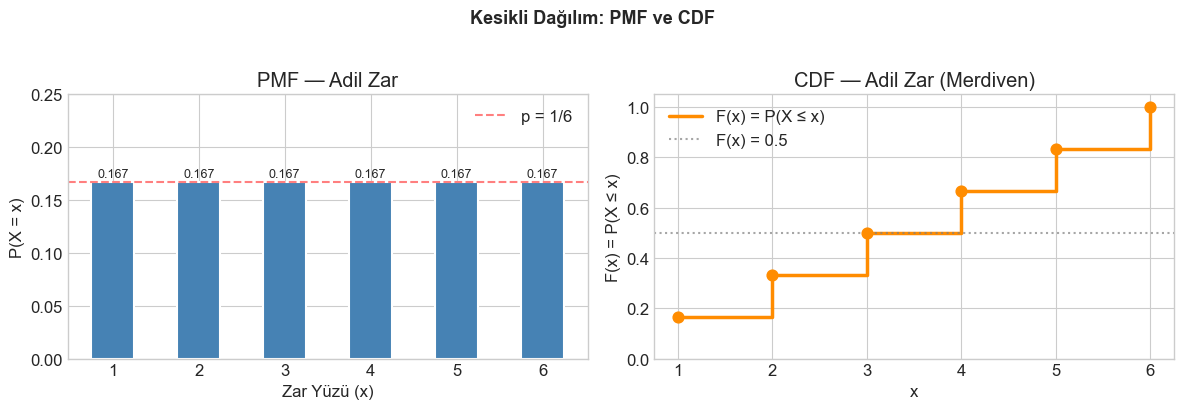


--- Örnek hesaplar ---
P(X = 4)         = 0.1667   ← PMF'ten doğrudan
P(X ≤ 4)         = 0.6667   ← CDF: ilk 4 yüzün toplamı
P(2 < X ≤ 5)     = 0.5000   ← F(5) - F(2)  [3,4,5 gelme]


In [98]:
# ── Veri tanımı ──────────────────────────────────────────────────────────────
faces   = np.array([1, 2, 3, 4, 5, 6])   # zarın yüzleri
pmf     = np.array([1/6]*6)               # her yüzün olasılığı: eşit dağılım
# pmf için np.ones(6)/6 veya stats.randint.pmf(faces, 1, 7) de kullanılabilir
cdf     = np.cumsum(pmf)                  # kümülatif toplam: [1/6, 2/6, 3/6, 4/6, 5/6, 1]
# cdf için stats.randint.cdf(faces, 1, 7) de kullanılabilir

print("Yüzler :", faces)
print("PMF    :", np.round(pmf, 4))
print("CDF    :", np.round(cdf, 4))
print("PMF toplamı:", pmf.sum(), "← 1 olmalı ✓")

# ── Grafik: yan yana iki panel ───────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- Sol panel: PMF bar chart ---
ax1.bar(
    faces,              # x ekseni: zar yüzleri
    pmf,                # y ekseni: olasılıklar
    width=0.5,          # çubuk genişliği — aralarında boşluk kalmalı (kesiklilik)
    color='steelblue',
    edgecolor='white',
    linewidth=1.5
)
ax1.set_xticks(faces)
ax1.set_ylim(0, 0.25)
ax1.axhline(1/6, color='red', linestyle='--', alpha=0.5, label='p = 1/6')
ax1.set_xlabel('Zar Yüzü (x)')
ax1.set_ylabel('P(X = x)')
ax1.set_title('PMF — Adil Zar')
ax1.legend()

# Her barın üstüne olasılık yaz
for face, prob in zip(faces, pmf):
    ax1.text(face, prob + 0.005, f'{prob:.3f}', ha='center', fontsize=9)

# --- Sağ panel: CDF merdiven grafiği ---
# 'post' parametresi: değer x'te değişiyor, x+1'den önce değil → merdiven efekti
ax2.step(
    faces,              # x değerleri
    cdf,                # y değerleri (kümülatif)
    where='post',       # basamağı sağa doğru çiz (x sonrası sabit kalır)
    color='darkorange',
    linewidth=2.5,
    label='F(x) = P(X ≤ x)'
)

# Dolgu noktaları: CDF'in tam olarak hangi değerde atladığını göster
ax2.scatter(faces, cdf, color='darkorange', zorder=5, s=60)

# Referans çizgisi: F(x) = 0.5 nerede?
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7, label='F(x) = 0.5')
ax2.set_xticks(faces)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel('x')
ax2.set_ylabel('F(x) = P(X ≤ x)')
ax2.set_title('CDF — Adil Zar (Merdiven)')
ax2.legend()

plt.suptitle('Kesikli Dağılım: PMF ve CDF', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Örnek hesap ──────────────────────────────────────────────────────────────
print("\n--- Örnek hesaplar ---")
print(f"P(X = 4)         = {pmf[3]:.4f}   ← PMF'ten doğrudan")
print(f"P(X ≤ 4)         = {cdf[3]:.4f}   ← CDF: ilk 4 yüzün toplamı")
print(f"P(2 < X ≤ 5)     = {cdf[4]-cdf[1]:.4f}   ← F(5) - F(2)  [3,4,5 gelme]")

---
## 📈 Hücre 2 — Normal Dağılım PDF + Alan Hesabı

**Ne yapıyoruz?**  
Normal PDF eğrisini çiziyor, belirli bir aralıktaki alanı (= olasılığı) gölgelendiriyoruz  
ve `scipy.integrate.quad` ile sayısal olarak hesaplıyoruz.

**Mantık:**  
- `scipy.stats.norm` → Normal dağılım nesnesi. `pdf(x)` yoğunluğu, `cdf(x)` kümülatifi verir.  
- `quad(f, a, b)` → $\int_a^b f(x)dx$ sayısal integrali hesaplar. Sonuç bir olasılık olmalı [0,1].  
- Alan gölgelendirmek: `ax.fill_between(x, y)` — sadece istenen aralıktaki x değerlerini seç.

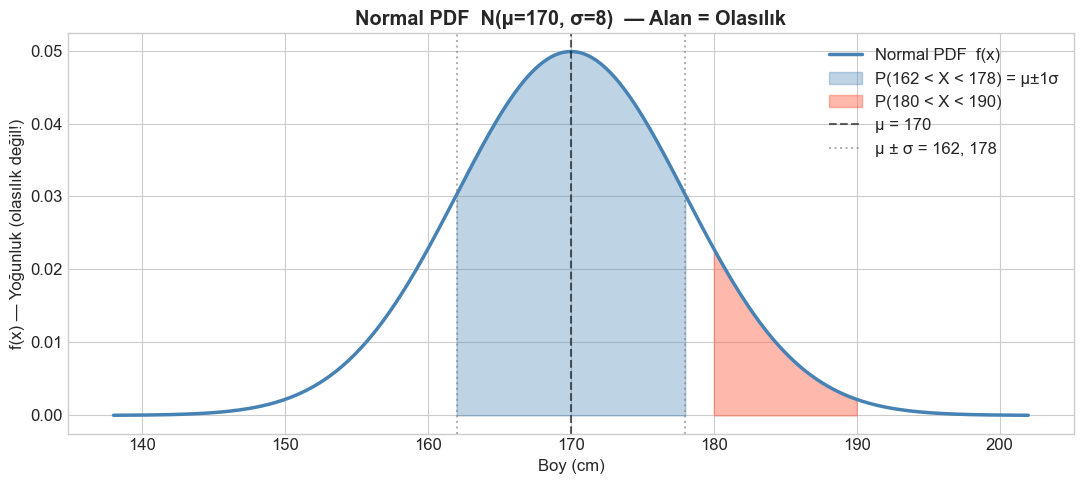

--- Alan = Olasılık hesapları ---
P(162 < X < 178)  = 0.6827  ← μ±1σ → ~%68.27 kuralı
P(180 < X < 190)  = 0.0994  ← kırmızı alan
P(X < 170)        = 0.5000  ← simetri: 0.5 olmalı ✓
Toplam alan       = 1.000000  ← 1 olmalı ✓

CDF ile aynı sonuç (fark yok):
P(162 < X < 178) via CDF = 0.6827


In [99]:
from scipy import integrate
# ── Dağılım parametreleri ─────────────────────────────────────────────────────
mu    = 170    # ortalama boy (cm)
sigma = 8      # standart sapma

# scipy.stats.norm → Normal dağılım nesnesi
# Tüm Normal metotlarına buradan erişiriz: .pdf(), .cdf(), .rvs() vb.
dist = stats.norm(loc=mu, scale=sigma) # N(μ=170, σ=8) dağılımı

# x ekseni: μ ± 4σ aralığı (pratikte tüm dağılımı kapsar)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400) # x ekseni: [138, 202] aralığı, 400 nokta
y = dist.pdf(x)   # her x noktasında PDF değeri (yoğunluk)

# ── Grafik ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# Temel PDF eğrisi
ax.plot(x, y, 'steelblue', linewidth=2.5, label='Normal PDF  f(x)')

# --- Alan 1: P(162 < X < 178) — μ ± 1σ bölgesi ---
x_fill1 = np.linspace(mu - sigma, mu + sigma, 200)  # [162, 178]
ax.fill_between(
    x_fill1, dist.pdf(x_fill1),
    alpha=0.35, color='steelblue',
    label=f'P(162 < X < 178) = μ±1σ'
)

# --- Alan 2: P(180 < X < 190) — sağ kuyruğun bir parçası ---
x_fill2 = np.linspace(180, 190, 200)
ax.fill_between(
    x_fill2, dist.pdf(x_fill2),
    alpha=0.45, color='tomato',
    label='P(180 < X < 190)'
)

# Dikey çizgiler: μ, μ±σ
ax.axvline(mu,          color='black',  linestyle='--', alpha=0.6, label=f'μ = {mu}')
ax.axvline(mu - sigma,  color='gray',   linestyle=':',  alpha=0.6)
ax.axvline(mu + sigma,  color='gray',   linestyle=':',  alpha=0.6, label=f'μ ± σ = {mu-sigma}, {mu+sigma}')

ax.set_xlabel('Boy (cm)')
ax.set_ylabel('f(x) — Yoğunluk (olasılık değil!)')
ax.set_title(f'Normal PDF  N(μ={mu}, σ={sigma})  — Alan = Olasılık', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ── Sayısal alan hesabı (quad) ────────────────────────────────────────────────
# quad() → (integral_değeri, hata_tahmini) döndürür
p1, _ = integrate.quad(dist.pdf, mu - sigma, mu + sigma)  # P(162 < X < 178)
p2, _ = integrate.quad(dist.pdf, 180, 190)                 # P(180 < X < 190)
p3, _ = integrate.quad(dist.pdf, -np.inf, mu)              # P(X < 170) → 0.5 olmalı (simetri)
p4, _ = integrate.quad(dist.pdf, mu - 10*sigma, mu + 10*sigma)          # toplam alan → 1 olmalı

print("--- Alan = Olasılık hesapları ---")
print(f"P(162 < X < 178)  = {p1:.4f}  ← μ±1σ → ~%68.27 kuralı")
print(f"P(180 < X < 190)  = {p2:.4f}  ← kırmızı alan")
print(f"P(X < 170)        = {p3:.4f}  ← simetri: 0.5 olmalı ✓")
print(f"Toplam alan       = {p4:.6f}  ← 1 olmalı ✓")
print()
print("CDF ile aynı sonuç (fark yok):")
print(f"P(162 < X < 178) via CDF = {dist.cdf(178) - dist.cdf(162):.4f}")

---
## 📉 Hücre 3 — Normal CDF: S Eğrisi + PDF ile Karşılaştırma

**Ne yapıyoruz?**  
PDF ve CDF'i yan yana çiziyor, aralarındaki matematiksel bağı görsel olarak kuruyoruz.

**Mantık:**  
- `dist.cdf(x)` → $F(x) = P(X \leq x)$. Sonsuz sayıda noktada çağrılabilir.  
- PDF'in tepesi ($x = \mu$) → CDF'in büküm noktasında (inflection) tam olarak $F(\mu) = 0.5$  
- Bir yerde PDF yüksekse, CDF orada hızla yükseliyor demektir.  
- Quantile (yüzdelik): `dist.ppf(0.90)` → %90 yüzdelik değeri (CDF'nin tersi)

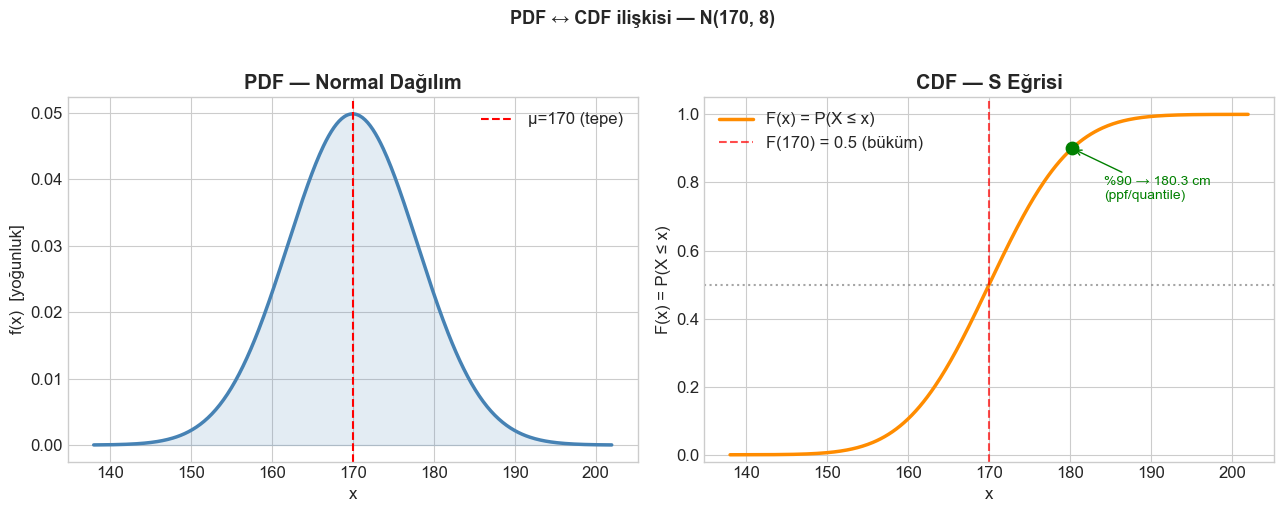

--- CDF ile pratik sorular ---
P(X < 160)        = 0.1056   → nüfusun %10.6'i 160'tan kısa
P(X > 185)        = 0.0304   → 185'ten uzun olma olasılığı
P(160 < X < 180)  = 0.7887
%90 yüzdelik      = 180.25 cm  → nüfusun %90'ı bu değerden kısa
%25 yüzdelik (Q1) = 164.60 cm
%75 yüzdelik (Q3) = 175.40 cm


In [100]:
# ── Aynı dağılımı kullanıyoruz: N(170, 8) ────────────────────────────────────
x   = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf_vals = dist.pdf(x)
cdf_vals = dist.cdf(x)   # her x için P(X ≤ x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Sol: PDF ---
ax1.plot(x, pdf_vals, 'steelblue', linewidth=2.5)
ax1.fill_between(x, pdf_vals, alpha=0.15, color='steelblue')
ax1.axvline(mu, color='red', linestyle='--', label=f'μ={mu} (tepe)')
ax1.set_title('PDF — Normal Dağılım', fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)  [yoğunluk]')
ax1.legend()

# --- Sağ: CDF ---
ax2.plot(x, cdf_vals, 'darkorange', linewidth=2.5, label='F(x) = P(X ≤ x)')

# Referans noktaları: F(μ) = 0.5
ax2.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
ax2.axvline(mu,  color='red',  linestyle='--', alpha=0.7, label=f'F({mu}) = 0.5 (büküm)')

# Quantile gösterimi: %90 yüzdelik
q90 = dist.ppf(0.90)    # ppf = percent point function = CDF'nin tersi
ax2.scatter([q90], [0.90], color='green', zorder=5, s=80)
ax2.annotate(
    f'%90 → {q90:.1f} cm\n(ppf/quantile)',
    xy=(q90, 0.90), xytext=(q90 + 4, 0.75),
    arrowprops=dict(arrowstyle='->', color='green'),
    color='green', fontsize=10
)

ax2.set_title('CDF — S Eğrisi', fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('F(x) = P(X ≤ x)')
ax2.set_ylim(-0.02, 1.05)
ax2.legend()

plt.suptitle('PDF ↔ CDF ilişkisi — N(170, 8)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── CDF ile olasılık soruları ─────────────────────────────────────────────────
print("--- CDF ile pratik sorular ---")
print(f"P(X < 160)        = {dist.cdf(160):.4f}   → nüfusun %{dist.cdf(160)*100:.1f}'i 160'tan kısa")
print(f"P(X > 185)        = {1 - dist.cdf(185):.4f}   → 185'ten uzun olma olasılığı")
print(f"P(160 < X < 180)  = {dist.cdf(180) - dist.cdf(160):.4f}")
print(f"%90 yüzdelik      = {q90:.2f} cm  → nüfusun %90'ı bu değerden kısa")
print(f"%25 yüzdelik (Q1) = {dist.ppf(0.25):.2f} cm")
print(f"%75 yüzdelik (Q3) = {dist.ppf(0.75):.2f} cm")

---
## 📊 Hücre 4 — Gerçek Veri: Histogram (`density=True`) vs KDE

**Ne yapıyoruz?**  
`tips` dataset'indeki `total_bill` (hesap tutarı) sütunu için ampirik PDF tahmini yapıyoruz.  
Histogram ve KDE'yi karşılaştırıyoruz, üstüne teorik Normal fit ekliyoruz.

**Mantık:**  
- `density=True` → histogram barlarının alanı toplamda 1 olur (frekans değil yoğunluk gösterir).  
  Bu sayede KDE ve teorik PDF eğrisiyle aynı y ekseninde karşılaştırılabilir.  
- **KDE (Kernel Density Estimation):** Her veri noktasının üstüne küçük bir çan eğrisi (kernel) koyar,  
  hepsini toplar → pürüzsüz PDF tahmini. Histogram'ın bin boyutuna duyarlı olmayan alternatifi.  
- **Normal fit:** Veriden $\hat{\mu}$ ve $\hat{\sigma}$ hesaplayıp teorik Normal PDF'i çiziyoruz.  
  Uyumsuzluk → verinin Normal olmadığını gösterir (burada sağa çarpık!).

Gözlem sayısı: 244
Ortalama     : 19.79 $
Std sapma    : 8.90 $
Min / Max    : 3.07 / 50.81 $

Normal fit → μ̂=19.79, σ̂=8.88


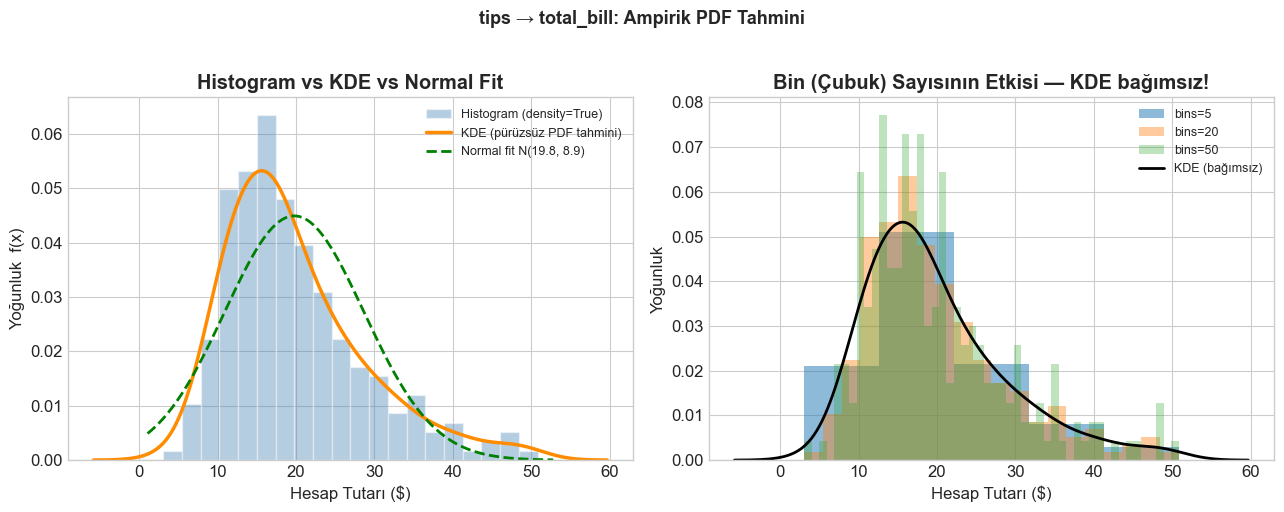


--- Gözlem ---
Veri sağa çarpık (right-skewed): kuyruk sağda uzuyor.
Normal fit uyumsuz → gerçek veri her zaman Normal değildir!
Histogram bin (çubuk) sayısına duyarlı; KDE daha kararlı bir tahmin verir.


In [109]:
# ── Veri yükleme ──────────────────────────────────────────────────────────────
tips = sns.load_dataset('tips')
data = tips['total_bill']   # 244 restoran faturası (dolar)

print(f"Gözlem sayısı: {len(data)}")
print(f"Ortalama     : {data.mean():.2f} $") # Ortalama formülü = Σx / n
print(f"Std sapma    : {data.std():.2f} $")  # Standard sapma formülü = √(Σ(x-μ)² / n)
print(f"Min / Max    : {data.min():.2f} / {data.max():.2f} $") 

# ── Normal fit: MLE ile μ ve σ tahmin et ──────────────────────────────────────
# stats.norm.fit() → (μ̂, σ̂) maksimum likelihood tahmini
mu_hat, sigma_hat = stats.norm.fit(data) # Burada μ̂ ve σ̂, veri setine en iyi uyan Normal dağılımın parametreleridir.
print(f"\nNormal fit → μ̂={mu_hat:.2f}, σ̂={sigma_hat:.2f}")

# ── Grafik ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_range = np.linspace(data.min() - 2, data.max() + 2, 300)

# --- Sol: Histogram vs KDE ---
ax = axes[0]

# Histogram: density=True → y ekseni yoğunluk (alan=1)
ax.hist(
    data,
    bins=20,            # kaç bin/çubuk
    density=True,       # ← kritik: yoğunluk modu
    alpha=0.4,
    color='steelblue',
    edgecolor='white',
    label='Histogram (density=True)'
)

# KDE: seaborn.kdeplot → pürüzsüz PDF tahmini
sns.kdeplot(
    data,
    ax=ax,
    color='darkorange',
    linewidth=2.5,
    label='KDE (pürüzsüz PDF tahmini)'
)

# Teorik Normal fit
ax.plot(
    x_range,
    stats.norm.pdf(x_range, mu_hat, sigma_hat),
    'green', linewidth=2, linestyle='--',
    label=f'Normal fit N({mu_hat:.1f}, {sigma_hat:.1f})'
)

ax.set_xlabel('Hesap Tutarı ($)')
ax.set_ylabel('Yoğunluk  f(x)')
ax.set_title('Histogram vs KDE vs Normal Fit', fontweight='bold')
ax.legend(fontsize=9)

# --- Sağ: Bin (çubuk) sayısının etkisi ---
ax = axes[1]
for bins, alpha, label in [(5, 0.5, 'bins=5'), (20, 0.4, 'bins=20'), (50, 0.3, 'bins=50')]:
    ax.hist(data, bins=bins, density=True, alpha=alpha, label=label)
sns.kdeplot(data, ax=ax, color='black', linewidth=2, label='KDE (bağımsız)')
ax.set_xlabel('Hesap Tutarı ($)')
ax.set_ylabel('Yoğunluk')
ax.set_title('Bin (Çubuk) Sayısının Etkisi — KDE bağımsız!', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('tips → total_bill: Ampirik PDF Tahmini', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Gözlem ---")
print("Veri sağa çarpık (right-skewed): kuyruk sağda uzuyor.")
print("Normal fit uyumsuz → gerçek veri her zaman Normal değildir!")
print("Histogram bin (çubuk) sayısına duyarlı; KDE daha kararlı bir tahmin verir.")

### Hücre 4 Açıklama

#### *Sol Grafik*
> *Restoran faturaları genellikle ne kadar?*
> 244 farklı fatura var ve bunları görselleştirip anlamak istiyoruz.

- Mavi Çubuklar -> Histogram
* 0-5 dolar arası kaç fatura
* 5-10 dolar arası kaç fatura 
* 10-15 dolar arası kaç fatura diye gidiyor

> Her grubun *çubuğu ne kadar yüksekse o kadar çok fatura vardır o kısımda!*
> Grafiğe bakıyoruz ve *15-20$* aralığında en fazla demekki bu kadar ödüyormuş çoğunlukla

#### *Sorun şu çubuğu kaç parçaya bölersek ona göre değişmez mi grafiğimiz?*

- Turuncu Eğri -> KDE
* *Histogramı parmağınla düzleştirsen* ve bu da sana histogram gibi bilgi verip pürüzsüz bir eğri oluştursa
* Hem histogramdaki bilgiler kaybolmayacak hemde çıkarım anlamında yardımcı olacak bize
> Avantajı ise kaç çubuğa gerek var onu söylemez gerçeği direkt önümüze sürer.

- Yeşil Kesikli Eğri -> Normal Fit (Çan Eğrisi)
* *Bu veri direkt NORMAL DAĞILIMDAN geliyormuş gibi* düşünsek nasıl olurdu?
* Verilerin ortalaması ve standart sapmasını hesapladı ve bize çan eğrisi çizdi
* Fakat uymadı çünkü gerçek fatura sağa çarpık yani 15-20 aralığında kümeleniyor dağılım.
* Bu da sağa çarpık olunca simetrikle eşit olmuyor
> Her veri NORMAL DAĞILMAZ!

#### *Sağ Grafik*

> Çubuk (Bin) sayısına göre buradan etkiyi görebiliriz
* 5 (Mavi) -> Çok detaysız ve kaba
* 20 (Turuncu) -> Makul seviyede
* 50 (Yeşil) -> Gürültüsü bol ve çok parçalı

> UNUTMA! KDE hiçbir şekilde bin sayısına bağlı değildir.


---
## 📐 Hücre 5 — ECDF: Ampirik Kümülatif Dağılım

**Ne yapıyoruz?**  
Gerçek veriden ECDF (Empirical CDF) hesaplıyor, teorik CDF ile karşılaştırıyor  
ve belirli bir aralıktaki olasılığı ECDF'ten okuyoruz.

**Mantık:**  
- **ECDF tanımı:** Verileri küçükten büyüğe sırala. $n$ veri noktasında ECDF değeri  
  her sıralı gözlemde $1/n$ kadar atlar.  
  $\hat{F}(x) = \frac{\text{x'e eşit veya küçük gözlem sayısı}}{n}$  
- **`scipy.stats.ecdf`:** Hesaplamayı otomatik yapar; `.cdf.evaluate(x)` ile istenen noktada CDF değeri okunur.  
- **Teorik vs Ampirik:** İkisi örtüşüyorsa, veri o dağılımdan geliyor demektir (görsel hipotez testi).  
- **KS testi:** İki CDF arasındaki maksimum farkı (D istatistiği) ölçer — ilerleyen derslerde.

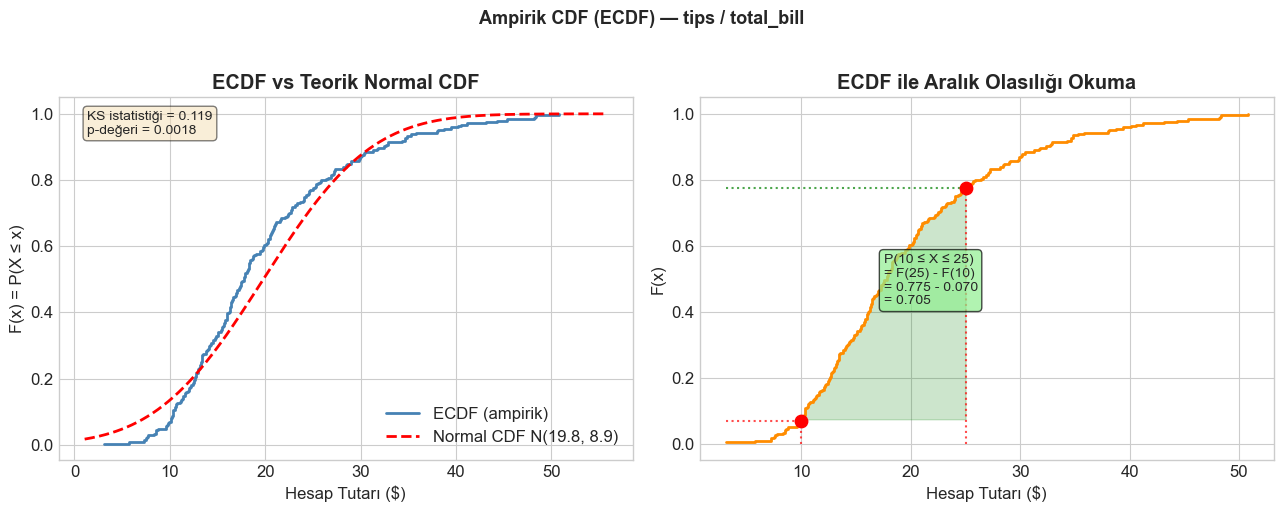

--- ECDF'ten olasılık okuma ---
F(10)  = P(X ≤ 10)  = 0.0697  → faturaların %7.0'i 10$'dan az
F(25)  = P(X ≤ 25)  = 0.7746  → faturaların %77.5'i 25$'dan az
P(10 ≤ X ≤ 25)      = 0.7049  → faturaların %70.5'i bu aralıkta

KS testi: D=0.119, p=0.0018
p < 0.05 → veri Normal dağılımdan gelmiyor (sağa çarpık olduğu için beklenen sonuç)


In [102]:
# ── ECDF hesabı ───────────────────────────────────────────────────────────────
# scipy.stats.ecdf → veriyi alır, ECDF nesnesi döner
ecdf_result = stats.ecdf(data)

# ECDF'nin tanımlı olduğu x değerleri (sıralanmış gözlemler)
x_sorted = np.sort(data.values)
# Her sıralı gözlem için ECDF değerleri: 1/n, 2/n, ..., n/n
y_ecdf   = np.arange(1, len(data) + 1) / len(data)

# ── Teorik CDF: Normal fit parametreleri ─────────────────────────────────────
x_range    = np.linspace(data.min() - 2, data.max() + 5, 300)
y_norm_cdf = stats.norm.cdf(x_range, mu_hat, sigma_hat)

# ── Grafik ───────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Sol: ECDF vs Teorik CDF ---
# ECDF: step plot (merdiven) — kesikli gözlem noktaları
ax1.step(
    x_sorted, y_ecdf,
    where='post',
    color='steelblue', linewidth=2,
    label='ECDF (ampirik)'
)
# Teorik Normal CDF
ax1.plot(
    x_range, y_norm_cdf,
    'red', linewidth=2, linestyle='--',
    label=f'Normal CDF N({mu_hat:.1f}, {sigma_hat:.1f})'
)

# KS istatistiği: maksimum fark
ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu_hat, sigma_hat))
ax1.text(
    0.05, 0.90,
    f'KS istatistiği = {ks_stat:.3f}\np-değeri = {ks_p:.4f}',
    transform=ax1.transAxes, fontsize=10,
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
)

ax1.set_xlabel('Hesap Tutarı ($)')
ax1.set_ylabel('F(x) = P(X ≤ x)')
ax1.set_title('ECDF vs Teorik Normal CDF', fontweight='bold')
ax1.legend()

# --- Sağ: ECDF'ten olasılık okuma ---
ax2.step(x_sorted, y_ecdf, where='post', color='darkorange', linewidth=2)

# P(10 ≤ X ≤ 25): ECDF'ten oku
# evaluate(): ECDF nesnesinden belirli x'te CDF değeri al
p_10 = ecdf_result.cdf.evaluate(10)
p_25 = ecdf_result.cdf.evaluate(25)
p_range = p_25 - p_10

# Okunan noktaları işaretle
ax2.scatter([10, 25], [p_10, p_25], color='red', zorder=5, s=80)
ax2.plot([10, 10], [0, p_10], 'r:', alpha=0.7)
ax2.plot([25, 25], [0, p_25], 'r:', alpha=0.7)
ax2.plot([data.min(), 25], [p_25, p_25], 'g:', alpha=0.7)
ax2.plot([data.min(), 10], [p_10, p_10], 'r:', alpha=0.7)

# Aralığı renklendir
mask = (x_sorted >= 10) & (x_sorted <= 25)
ax2.fill_between(
    x_sorted[mask], y_ecdf[mask], y_ecdf[mask][0],
    alpha=0.2, color='green'
)

ax2.annotate(
    f'P(10 ≤ X ≤ 25)\n= F(25) - F(10)\n= {p_25:.3f} - {p_10:.3f}\n= {p_range:.3f}',
    xy=(17.5, (p_10 + p_25)/2), fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7)
)

ax2.set_xlabel('Hesap Tutarı ($)')
ax2.set_ylabel('F(x)')
ax2.set_title('ECDF ile Aralık Olasılığı Okuma', fontweight='bold')

plt.suptitle('Ampirik CDF (ECDF) — tips / total_bill', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Sayısal sonuçlar ──────────────────────────────────────────────────────────
print("--- ECDF'ten olasılık okuma ---")
print(f"F(10)  = P(X ≤ 10)  = {p_10:.4f}  → faturaların %{p_10*100:.1f}'i 10$'dan az")
print(f"F(25)  = P(X ≤ 25)  = {p_25:.4f}  → faturaların %{p_25*100:.1f}'i 25$'dan az")
print(f"P(10 ≤ X ≤ 25)      = {p_range:.4f}  → faturaların %{p_range*100:.1f}'i bu aralıkta")
print()
print(f"KS testi: D={ks_stat:.3f}, p={ks_p:.4f}")
print("p < 0.05 → veri Normal dağılımdan gelmiyor (sağa çarpık olduğu için beklenen sonuç)")

### Hücre 5 Açıklaması

#### *Sol Grafik*
> *Faturaların kaçta kaçı X dolardan az?*

#### Mavi Eğri -> ECDF (Ampirik CDF)
* Gerçekten veriden 244 veri aldık e hepsini küçükten büyüğe sıraladık ardından her yeni faturada eğri daha da yükseliyor
* Örneğin X = 20$ dolar olduğunda Y = yaklaşık 0.65 -> Yüzde 65'i dolardan az
* Eğri sola yatıksa en başta hızlı yükselir ve bu şekilde sağa çarpık olduğunu anlarız
* Tam tersi olsaydı ilk kısımlarda yavaş yükselir sonra doğru fırlardı ve ona göre sola çarpık derdik
* Çoğu fatura düşükmüş demekki

#### Kırmızı Eğri -> CDF
* Normal dağılım olsaydı nasıl olurdu?
* Veri normal olamaz çünkü baktığımızda da gene sola doğru bir geriye takıklık görüyoruz yani normal düşük fatura olasılığını daha az tahmin ediyor.

#### KS İstatistiği ve P-Değeri -> İki eğri birbirinden ne kadar farklı?
* KS der ki iki eğri arasındaki maksimum dikey mesafe nedir?
* P-değeri der ki bu fark tesadüf müdür peki?

#### *Sağ Grafik*

> Faturaların kaçta kaçı 10$ ile 25$ arasında?

Adım adım okuma:
1. x=10$'a git, yukarı çık, eğriye çarp → Y ≈ 0.070
→ "Faturaların %7'si 10 dolardan az"

2. x=25$'a git, yukarı çık, eğriye çarp → Y ≈ 0.775
→ "Faturaların %77.5'i 25 dolardan az"

3. Farkı al: 0.775 − 0.070 = 0.705
→ "Faturaların %70.5'i 10 ile 25 arasında"

Yeşil alan tam bu bölgeyi gösteriyor.

---
### 🎲 R 1 — Zar: PMF ve CDF

Python'da `np.cumsum()` ile yaptığımız şeyi R'da `cumsum()` ile yapıyoruz —  
işlev tamamen aynı, sadece sözdizimi farklı.

`barplot()` → bar chart (PMF için)  
`plot(..., type='s')` → step/merdiven tipi çizgi (CDF için)  
`par(mfrow=c(1,2))` → grafikleri yan yana koy (Python'daki `subplots(1,2)` gibi)

PMF: 0.167 0.167 0.167 0.167 0.167 0.167 
CDF: 0.167 0.333 0.5 0.667 0.833 1 
Toplam: 1 

--- R ile hesaplar ---
P(X = 4)     = 0.1666667 
P(X ≤ 4)     = 0.6666667 
P(2 < X ≤ 5) = 0.5  ← cdf[5] - cdf[2]


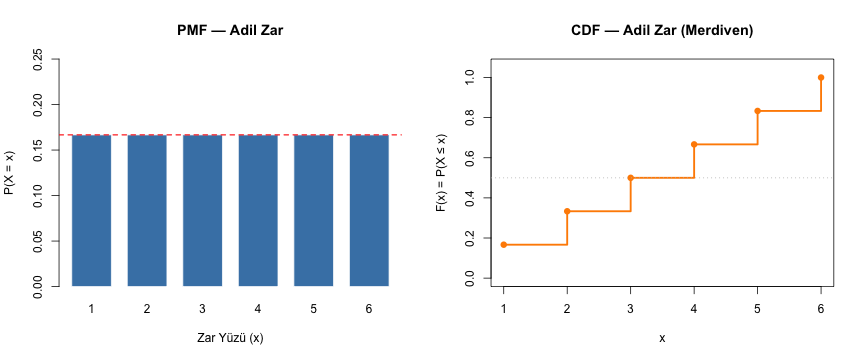

In [103]:
%%R -w 12 -h 5 --units in
# Zar değerleri ve olasılıkları
faces <- 1:6
pmf   <- rep(1/6, 6)          # rep(): değeri 6 kez tekrarla
cdf   <- cumsum(pmf)          # cumsum(): kümülatif toplam (Python'daki np.cumsum ile aynı)

cat("PMF:", round(pmf, 3), "\n")
cat("CDF:", round(cdf, 3), "\n")
cat("Toplam:", sum(pmf), "\n")

# Yan yana grafik: sol = PMF, sağ = CDF
par(mfrow = c(1, 2))  # 1 satır, 2 sütun

# --- PMF: barplot ---
# names.arg → x eksenindeki etiketler
# space=0.4 → çubuklar arası boşluk (kesikliği göstermek için)
barplot(
  pmf,
  names.arg = faces,
  col       = "steelblue",
  border    = "white",
  ylim      = c(0, 0.25),
  space     = 0.4,
  main      = "PMF — Adil Zar",
  xlab      = "Zar Yüzü (x)",
  ylab      = "P(X = x)"
)
abline(h = 1/6, col = "red", lty = 2, lwd = 1.5)   # yatay kırmızı referans

# --- CDF: step/merdiven grafik ---
# type='s' → merdiven (step) çizgisi
# pch=16   → dolu nokta sembolü
plot(
  faces, cdf,
  type = "s",             # ← merdiven tipi
  col  = "darkorange",
  lwd  = 2.5,
  ylim = c(0, 1.05),
  main = "CDF — Adil Zar (Merdiven)",
  xlab = "x",
  ylab = "F(x) = P(X ≤ x)"
)
points(faces, cdf, pch = 16, col = "darkorange", cex = 1.2)  # nokta işaretleri
abline(h = 0.5, col = "gray", lty = 3)                       # F(x)=0.5 referansı

# Grafik başlığını sıfırla
par(mfrow = c(1, 1))

# Hesap örnekleri
cat("\n--- R ile hesaplar ---\n")
cat("P(X = 4)     =", pmf[4], "\n")
cat("P(X ≤ 4)     =", cdf[4], "\n")
cat("P(2 < X ≤ 5) =", cdf[5] - cdf[2], " ← cdf[5] - cdf[2]\n")

---
### 📈 R 2 — Normal: PDF Eğrisi + Alan

R'da `dnorm(x, mean, sd)` → PDF değeri (Python'daki `dist.pdf(x)`)  
`pnorm(q, mean, sd)` → CDF değeri (Python'daki `dist.cdf(q)`)  
`curve()` → bir fonksiyonu belirtilen aralıkta çizer (scipy'ın `plot + linspace` ikilisinin kısayolu)  

Alan hesabı için `integrate()` fonksiyonu kullanırız —  
Python'daki `scipy.integrate.quad()` ile birebir aynı amaca hizmet eder.

--- integrate() ile alan hesabı ---
P(162 < X < 178): 0.6827 ← mavi alan
P(180 < X < 190): 0.0994 ← kırmızı alan

--- pnorm() kısayolu (aynı sonuç) ---
P(162 < X < 178): 0.6827 
P(X < 160):        0.1056 
%90 yüzdelik:      180.25 cm


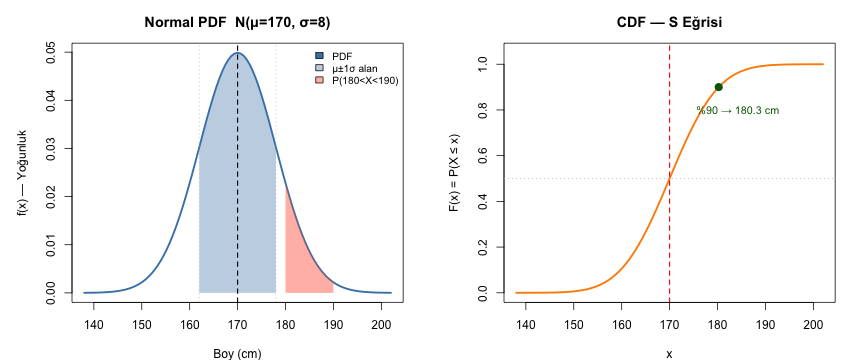

In [104]:
%%R -w 12 -h 5 --units in
mu    <- 170
sigma <- 8


# Boşlukları uygulayın
options(repr.plot.width = 12, repr.plot.height = 5)
par(mfrow = c(1, 2), mar = c(4,5,3,2))

# --- Sol: PDF eğrisi ---
# curve(): x'i otomatik üretip verdiğin fonksiyonu çizer
curve(
  dnorm(x, mean = mu, sd = sigma),   # ← her x için PDF değeri
  from = mu - 4*sigma,
  to   = mu + 4*sigma,
  col  = "steelblue",
  lwd  = 2.5,
  main = paste("Normal PDF  N(μ=", mu, ", σ=", sigma, ")", sep=""),
  xlab = "Boy (cm)",
  ylab = "f(x) — Yoğunluk"
)

# μ ± 1σ alanını (mavi) gölgele
# polygon() → kapalı şekil doldurma
x_fill <- seq(mu - sigma, mu + sigma, length.out = 200)
y_fill <- dnorm(x_fill, mu, sigma)
polygon(
  c(mu - sigma, x_fill, mu + sigma),  # x noktaları (başlangıç ve bitiş sıfıra iner)
  c(0, y_fill, 0),                    # y noktaları
  col    = adjustcolor("steelblue", alpha.f = 0.35),
  border = NA
)

# Kırmızı alan: P(180 < X < 190)
x_red <- seq(180, 190, length.out = 200)
polygon(c(180, x_red, 190), c(0, dnorm(x_red, mu, sigma), 0),
        col = adjustcolor("tomato", alpha.f = 0.45), border = NA)

abline(v = mu,          col = "black", lty = 2, lwd = 1.5)
abline(v = c(mu-sigma, mu+sigma), col = "gray", lty = 3)

legend("topright", legend = c("PDF", "μ±1σ alan", "P(180<X<190)"),
       fill = c("steelblue", adjustcolor("steelblue", 0.35), adjustcolor("tomato", 0.45)),
       bty = "n", cex = 0.85)

# --- Sağ: CDF S eğrisi ---
curve(
  pnorm(x, mean = mu, sd = sigma),   # ← CDF: P(X ≤ x)
  from = mu - 4*sigma,
  to   = mu + 4*sigma,
  col  = "darkorange",
  lwd  = 2.5,
  ylim = c(0, 1.05),
  main = "CDF — S Eğrisi",
  xlab = "x",
  ylab = "F(x) = P(X ≤ x)"
)
abline(h = 0.5, col = "gray", lty = 3)
abline(v = mu,  col = "red",  lty = 2, lwd = 1.5)

# %90 yüzdelik: qnorm() → Python'daki ppf() ile aynı
q90 <- qnorm(0.90, mean = mu, sd = sigma)
points(q90, 0.90, col = "darkgreen", pch = 16, cex = 1.5)
text(q90 + 4, 0.80, paste0("%90 → ", round(q90, 1), " cm"), col = "darkgreen", cex = 0.9)

par(mfrow = c(1, 1))

# --- Alan hesapları ---
cat("--- integrate() ile alan hesabı ---\n")
p1 <- integrate(dnorm, mu-sigma, mu+sigma, mean=mu, sd=sigma)$value
p2 <- integrate(dnorm, 180, 190, mean=mu, sd=sigma)$value
cat("P(162 < X < 178):", round(p1, 4), "← mavi alan\n")
cat("P(180 < X < 190):", round(p2, 4), "← kırmızı alan\n")

# pnorm() ile aynı: integral almaya gerek yok
cat("\n--- pnorm() kısayolu (aynı sonuç) ---\n")
cat("P(162 < X < 178):", round(pnorm(178,mu,sigma) - pnorm(162,mu,sigma), 4), "\n")
cat("P(X < 160):       ", round(pnorm(160, mu, sigma), 4), "\n")
cat("%90 yüzdelik:     ", round(q90, 2), "cm\n")

---
### 📊 R 3 — tips verisi: Histogram + KDE + ECDF

Python'da `seaborn.load_dataset('tips')` ile yüklediğimiz veriyi  
R'da doğrudan `ggplot2`'nin içindeki `diamonds` benzeri veri setleri veya CSV'den yükleyebiliriz.  
Burada `rpy2` aracılığıyla Python'dan R'a aktarıyoruz — zaten elimizde var.

`hist(..., freq=FALSE)` → Python'daki `density=True` ile aynı şey. Alan = 1 olur.  
`density()` → R'da KDE — `seaborn.kdeplot()` karşılığı  
`ecdf()` → R'da ampirik CDF fonksiyonu üretir; `plot(ecdf(x))` ile çizilir  
`ks.test()` → Kolmogorov-Smirnov testi — Python'daki `stats.kstest()` karşılığı

Ortalama: 19.79 $
Std sapma: 8.9 $

--- KS Testi ---
D statistic: 0.119 
p-value:     0.0021 
p < 0.05 → veri Normal dagilmiyor
P(10 <= X <= 25) = 0.7049 


In addition: Warning message:
In ks.test.default(bill, "pnorm", mean = mu_r, sd = sd_r) :
  ties should not be present for the one-sample Kolmogorov-Smirnov test


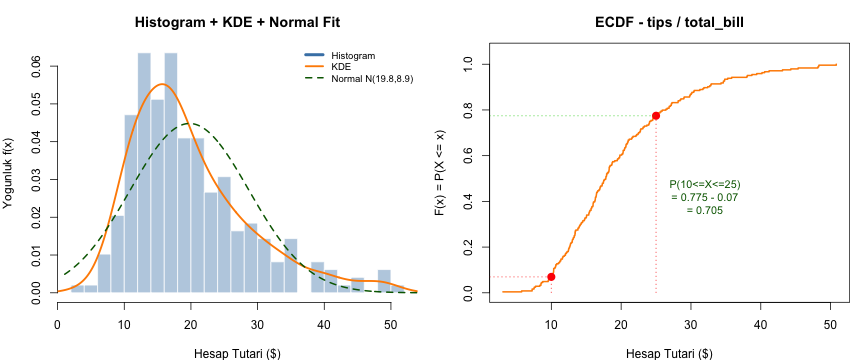

In [129]:
%%R -i tips -w 12 -h 5 --units in
# -i tips: Python'daki tips DataFrame'ini R'a aktar

bill <- tips$total_bill
mu_r <- mean(bill)
sd_r <- sd(bill)

cat("Ortalama:", round(mu_r, 2), "$\n")
cat("Std sapma:", round(sd_r, 2), "$\n")

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# --- Sol: Histogram + KDE + Normal fit ---
# freq=FALSE: y ekseni yogunluk (alan=1) — Python density=True ile ayni
hist(
  bill,
  breaks = 20,
  freq   = FALSE,
  col    = adjustcolor("steelblue", alpha.f = 0.4),
  border = "white",
  main   = "Histogram + KDE + Normal Fit",
  xlab   = "Hesap Tutari ($)",
  ylab   = "Yogunluk f(x)"
)
lines(density(bill), col = "darkorange", lwd = 2.5)

x_seq <- seq(min(bill) - 2, max(bill) + 5, length.out = 300)
lines(x_seq, dnorm(x_seq, mean = mu_r, sd = sd_r),
      col = "darkgreen", lwd = 2, lty = 2)

legend("topright",
       legend = c("Histogram", "KDE",
                  paste0("Normal N(", round(mu_r,1), ",", round(sd_r,1), ")")),
       col = c("steelblue", "darkorange", "darkgreen"),
       lwd = c(4, 2.5, 2), lty = c(1,1,2), bty = "n", cex = 0.8)

# --- Sag: ECDF ---
x_sorted <- sort(bill)
y_ecdf   <- seq_along(x_sorted) / length(x_sorted)

plot(
  x_sorted, y_ecdf,
  type = "s",
  col  = "darkorange",
  lwd  = 2,
  ylim = c(0, 1.05),
  main = "ECDF - tips / total_bill",
  xlab = "Hesap Tutari ($)",
  ylab = "F(x) = P(X <= x)"
)

# P(10 <= X <= 25) okuma
# sum(bill <= 10) / length(bill): Python'daki ecdf_obj.cdf.evaluate(10) ile ayni
p_10 <- sum(bill <= 10) / length(bill)
p_25 <- sum(bill <= 25) / length(bill)

points(c(10, 25), c(p_10, p_25), col = "red", pch = 16, cex = 1.5)
segments(10, 0,    10, p_10, col = "red",    lty = 3)
segments(25, 0,    25, p_25, col = "red",    lty = 3)
segments(0,  p_10, 10, p_10, col = "red",    lty = 3)
segments(0,  p_25, 25, p_25, col = "green3", lty = 3)

text(32, 0.42,
     paste0("P(10<=X<=25)\n= ", round(p_25,3),
            " - ", round(p_10,3),
            "\n= ",  round(p_25 - p_10, 3)),
     col = "darkgreen", cex = 0.9)

par(mfrow = c(1, 1))

ks_r <- ks.test(bill, "pnorm", mean = mu_r, sd = sd_r)
cat("\n--- KS Testi ---\n")
cat("D statistic:", round(ks_r$statistic, 3), "\n")
cat("p-value:    ", round(ks_r$p.value,   4), "\n")
cat("p < 0.05 → veri Normal dagilmiyor\n")
cat("P(10 <= X <= 25) =", round(p_25 - p_10, 4), "\n")


---
# 🗄️ SQL Uygulaması (DuckDB)

Python ve R'da gördüklerimizin aynısını SQL'de yapıyoruz:  
- Zar PMF → `GROUP BY` + frekans hesabı  
- Histogram (ampirik PDF) → `FLOOR()` ile bucket'lara böl  
- ECDF → `COUNT(*) OVER (ORDER BY x)` window function  
- Aralık olasılığı → ECDF değerlerinden fark

## SQL'de Yeni Kavram: Window Function

Normal `COUNT(*)` tablodaki **tüm satırları** sayar.  
Window function ise her satır için **o ana kadar kaç satır geldiğini** hesaplar —  
tıpkı Python'daki `np.cumsum()` gibi, ama SQL'de.

```sql
COUNT(*) OVER (ORDER BY x)   -- x'e göre sıralı kümülatif sayım
```

Bu, ECDF'in tam matematiksel karşılığıdır.

In [118]:
import duckdb
import pandas as pd

# DuckDB bağlantısı ve tips verisini kayıt et
# DuckDB doğrudan pandas DataFrame'i tablo gibi okuyabilir
con = duckdb.connect()
con.register('tips', tips)    # 'tips' adıyla SQL'de kullanılabilir hale getir

print("DuckDB hazır ✓")
print(f"tips tablosunda {len(tips)} satır var.")

DuckDB hazır ✓
tips tablosunda 244 satır var.


---
### 🎲 SQL 1 — Zar PMF: GROUP BY ile Frekans Tablosu

SQL'de PMF hesabı şudur:
1. Her değerin kaç kez göründüğünü say (`COUNT(*)`)
2. Toplam gözlem sayısına böl → olasılık

Burada zar atmayı simüle ediyoruz:  
`generate_series(1, 6)` → 1'den 6'ya kadar sayı üretir (zar yüzleri)

In [ ]:
# Adil zar PMF: her yüzün teorik olasılığı
# generate_series → DuckDB'de 1'den 6'ya dizi üretiyor
pmf_zar = con.execute("""
    SELECT
        face                             AS yuz,
        COUNT(*) AS gozlem_sayisi,
        gozlem_sayisi / SUM(COUNT(*)) OVER ()      AS pmf_olasilik,  -- gozlem sayısı / toplam gözlem sayısı
        SUM(COUNT(*)) OVER (ORDER BY face) * 1.0 / SUM(COUNT(*)) OVER() AS cdf_deger -- kümülatif toplam / toplam gözlem sayısı
    FROM (
        SELECT unnest(generate_series(1, 6)) AS face  -- her yüzden 1 satır -- 1,2,3,4,5,6
    )
    GROUP BY face
    ORDER BY face
""").df()

print("=== Adil Zar — PMF ve CDF ===")
print(pmf_zar.to_string(index=False))
print(f"\nPMF toplamı: {pmf_zar['pmf_olasilik'].sum():.4f}  ← 1 olmalı ✓")

=== Adil Zar — PMF ve CDF ===
 yuz  gozlem_sayisi  pmf_olasilik  cdf_deger
   1              1      0.166667   0.166667
   2              1      0.166667   0.333333
   3              1      0.166667   0.500000
   4              1      0.166667   0.666667
   5              1      0.166667   0.833333
   6              1      0.166667   1.000000

PMF toplamı: 1.0000  ← 1 olmalı ✓


---
### 📊 SQL 2 — tips: Histogram (Ampirik PDF Yaklaşımı)

Sürekli bir değişkeni (total_bill) bucket'lara bölüp frekansını sayıyoruz.  
Bu, histogram çizmekle aynı şeydir — sadece SQL'de tablo olarak.

`FLOOR(total_bill / 5) * 5` →  
- 12.3$ → `FLOOR(12.3/5)*5` = `FLOOR(2.46)*5` = `2*5` = **10** (10-15$ bucket'ı)
- 17.8$ → `FLOOR(17.8/5)*5` = `FLOOR(3.56)*5` = `3*5` = **15** (15-20$ bucket'ı)

Yani her faturayı en yakın 5$'ın katına yuvarlıyoruz.

In [ ]:
# Histogram: 5 dolarlık aralıklara böl, her aralıkta kaç fatura var?
hist_sql = con.execute("""
    SELECT
        -- Faturayı 5$'lık bucket'a yuvarla
        FLOOR(total_bill / 5) * 5        AS aralik_baslangic,
        FLOOR(total_bill / 5) * 5 + 5   AS aralik_bitis,
        COUNT(*)                          AS fatura_sayisi,
        -- Yoğunluk = frekans / (toplam * bin_genisligi)
        -- Bu, histogram density=True ile aynı hesap
        ROUND(
            fatura_sayisi
            / SUM(COUNT(*)) OVER ()  -- frekans oranı
            / 5.0,                   -- bin genişliğine böl → yoğunluk
        4) AS yogunluk
    FROM tips
    GROUP BY FLOOR(total_bill / 5)
    ORDER BY aralik_baslangic
""").df()

print("=== tips — Histogram (5$ aralıklar) ===")
print(hist_sql.to_string(index=False))

# Kontrol: yoğunluk * bin_genislik toplamı = 1 olmalı (ampirik PDF koşulu)
toplam_alan = (hist_sql['yogunluk'] * 5).sum()
print(f"\nToplam alan (∑ yoğunluk × genişlik) = {toplam_alan:.4f}  ← 1'e yakın olmalı ✓")

=== tips — Histogram (5$ aralıklar) ===
 aralik_baslangic  aralik_bitis  fatura_sayisi  yogunluk
              0.0           5.0              1    0.0008
              5.0          10.0             16    0.0131
             10.0          15.0             63    0.0516
             15.0          20.0             67    0.0549
             20.0          25.0             41    0.0336
             25.0          30.0             24    0.0197
             30.0          35.0             16    0.0131
             35.0          40.0              6    0.0049
             40.0          45.0              5    0.0041
             45.0          50.0              4    0.0033
             50.0          55.0              1    0.0008

Toplam alan (∑ yoğunluk × genişlik) = 0.9995  ← 1'e yakın olmalı ✓


---
### 📐 SQL 3 — tips: ECDF ve Aralık Olasılığı

ECDF'i SQL'de şöyle hesaplıyoruz:  
Her fatura için → "bu faturaya kadar kaç fatura var?" / toplam fatura sayısı

```sql
COUNT(*) OVER (ORDER BY total_bill)  -- kümülatif sayım
    * 1.0 / COUNT(*) OVER ()         -- orana çevir
```

Bu, Python'da yaptığımız `np.arange(1, n+1) / n` ile tamamen aynı şey —  
sadece SQL sözdiziminde.

In [123]:
# Her fatura için ECDF değerini hesapla
ecdf_sql = con.execute("""
    SELECT
        total_bill,
        -- Kümülatif satır sayısı / toplam satır = ECDF değeri
        COUNT(*) OVER (ORDER BY total_bill
                       ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
            * 1.0 / COUNT(*) OVER ()    AS ecdf_deger
    FROM tips
    ORDER BY total_bill
""").df()

print("=== ECDF — İlk 10 satır ===")
print(ecdf_sql.head(10).to_string(index=False))
print("...")
print("=== Son 5 satır ===")
print(ecdf_sql.tail(5).to_string(index=False))

# Aralık olasılığı: P(10 ≤ X ≤ 25)
# En yakın fatura değerlerinden ECDF oku
aralik_sql = con.execute("""
    WITH ecdf AS (
        SELECT
            total_bill,
            COUNT(*) OVER (ORDER BY total_bill
                           ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW)
                * 1.0 / COUNT(*) OVER () AS ecdf_deger
        FROM tips
    )
    SELECT
        -- F(10): 10$'dan küçük veya eşit faturaların oranı
        MAX(CASE WHEN total_bill <= 10 THEN ecdf_deger ELSE 0 END) AS F_10,
        -- F(25): 25$'dan küçük veya eşit faturaların oranı
        MAX(CASE WHEN total_bill <= 25 THEN ecdf_deger ELSE 0 END) AS F_25,
        -- P(10 ≤ X ≤ 25) = F(25) - F(10)
        MAX(CASE WHEN total_bill <= 25 THEN ecdf_deger ELSE 0 END)
        - MAX(CASE WHEN total_bill <= 10 THEN ecdf_deger ELSE 0 END) AS P_aralik
    FROM ecdf
""").df()

print("\n=== Aralık Olasılığı ===")
print(f"F(10)  = P(X ≤ 10) = {aralik_sql['F_10'][0]:.4f}")
print(f"F(25)  = P(X ≤ 25) = {aralik_sql['F_25'][0]:.4f}")
print(f"P(10 ≤ X ≤ 25)     = {aralik_sql['P_aralik'][0]:.4f}")
print("\n← Python ile karşılaştır: aynı sonuç olmalı ✓")

=== ECDF — İlk 10 satır ===
 total_bill  ecdf_deger
       3.07    0.004098
       5.75    0.008197
       7.25    0.012295
       7.25    0.016393
       7.51    0.020492
       7.56    0.024590
       7.74    0.028689
       8.35    0.032787
       8.51    0.036885
       8.52    0.040984
...
=== Son 5 satır ===
 total_bill  ecdf_deger
      45.35    0.983607
      48.17    0.987705
      48.27    0.991803
      48.33    0.995902
      50.81    1.000000

=== Aralık Olasılığı ===
F(10)  = P(X ≤ 10) = 0.0697
F(25)  = P(X ≤ 25) = 0.7746
P(10 ≤ X ≤ 25)     = 0.7049

← Python ile karşılaştır: aynı sonuç olmalı ✓


---
### 📏 SQL 4 — Quantile: CDF'nin Tersi

Python'da `dist.ppf(0.90)` ve R'da `qnorm(0.90)` ile yaptığımızı SQL'de de yapabiliriz.  
DuckDB'nin `QUANTILE_CONT()` fonksiyonu tam olarak budur.

`QUANTILE_CONT(col, 0.90)` → "verinin %90'ı bu değerin altında" diye cevap verir.

In [124]:
# Quantile hesapları: CDF'nin tersi
quantile_sql = con.execute("""
    SELECT
        MIN(total_bill)                   AS minimum,
        QUANTILE_CONT(total_bill, 0.25)   AS Q1_yuzde25,    -- %25 yüzdelik
        QUANTILE_CONT(total_bill, 0.50)   AS medyan_yuzde50,-- medyan = %50
        QUANTILE_CONT(total_bill, 0.75)   AS Q3_yuzde75,    -- %75 yüzdelik
        QUANTILE_CONT(total_bill, 0.90)   AS yuzde90,       -- %90 yüzdelik
        QUANTILE_CONT(total_bill, 0.95)   AS yuzde95,
        MAX(total_bill)                   AS maksimum
    FROM tips
""").df()

print("=== Quantile Tablosu ===")
print(quantile_sql.to_string(index=False))

# Gruplu quantile: kadın vs erkek
quantile_grup = con.execute("""
    SELECT
        sex                               AS cinsiyet,
        COUNT(*)                          AS fatura_sayisi,
        ROUND(AVG(total_bill), 2)         AS ortalama,
        ROUND(QUANTILE_CONT(total_bill, 0.50), 2) AS medyan,
        ROUND(QUANTILE_CONT(total_bill, 0.75), 2) AS Q3,
        ROUND(QUANTILE_CONT(total_bill, 0.90), 2) AS yuzde90
    FROM tips
    GROUP BY sex
    ORDER BY sex
""").df()

print("\n=== Cinsiyete Göre Quantile ===")
print(quantile_grup.to_string(index=False))

=== Quantile Tablosu ===
 minimum  Q1_yuzde25  medyan_yuzde50  Q3_yuzde75  yuzde90  yuzde95  maksimum
    3.07     13.3475          17.795     24.1275   32.235   38.061     50.81

=== Cinsiyete Göre Quantile ===
cinsiyet  fatura_sayisi  ortalama  medyan    Q3  yuzde90
    Male            157     20.74   18.35 24.71    32.86
  Female             87     18.06   16.40 21.52    28.82


---
## ✏️ Egzersizler

**E1.** Bir bozuk para 60:40 önyargılıdır ($P(\text{Yazı})=0.6$).  
- PMF'yi yazın ve bar chart çizin 

**E2.** `total_bill` yerine `tip` (bahşiş) sütununu kullan.  
- Histogram + KDE + ECDF'i Python'da çiz  
- $P(1 \leq \text{tip} \leq 3)$ değerini hesapla

**E3 (SQL).** `time` (Lunch/Dinner) ve `day` gruplarına göre ayrı ECDF değerlerini hesapla.  
Hangi gün en yüksek faturalar ödeniyor?

**E4 (R).** R'da `qqnorm(bill)` çalıştır — QQ-Plot nedir, ne söylüyor?



--- Egzersiz 1: Hileli Para ---
PMF: [0.6 0.4]


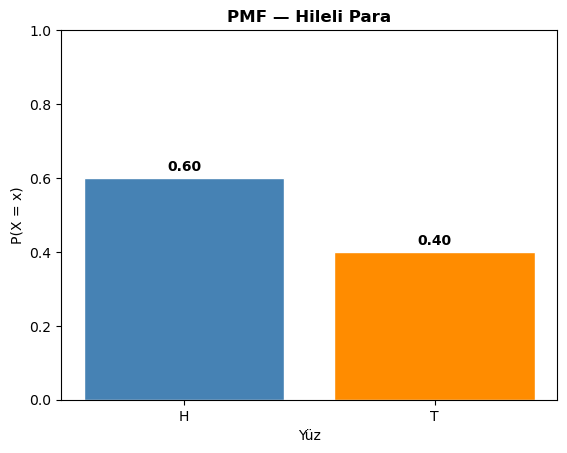

KS istatistiği = 0.101, p-değeri = 0.0123


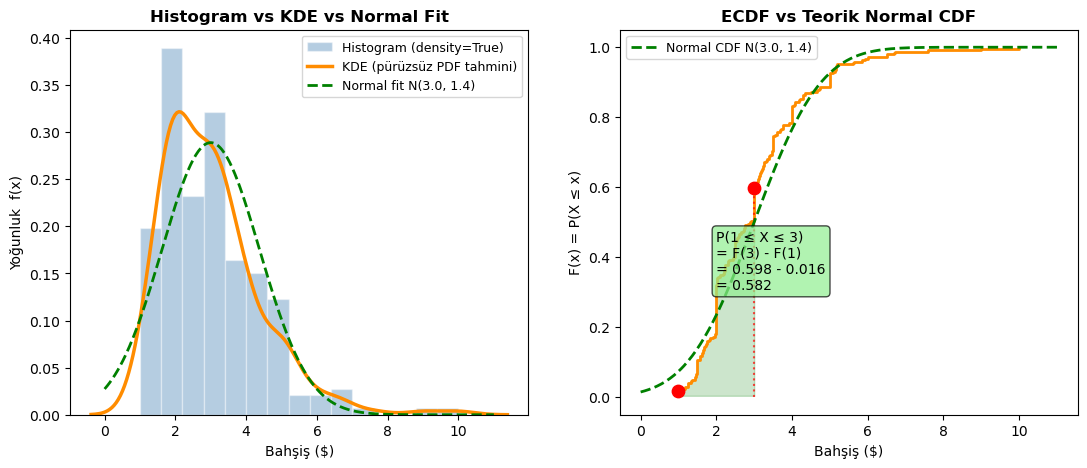

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


# ===== Egzersiz 1 (Python) =====
faces = np.array(["H", "T"])  # H: Heads, T: Tails
pmf_coin = np.array([0.6, 0.4])  # Hileli bir para: P(H)=0.6, P(T)=0.4
print("\n--- Egzersiz 1: Hileli Para ---")
print("PMF:", np.round(pmf_coin, 3))

plt.bar(faces, pmf_coin, color=['steelblue', 'darkorange'], edgecolor='white')
plt.title("PMF — Hileli Para", fontweight='bold')
plt.xlabel("Yüz")
plt.ylabel("P(X = x)")
plt.ylim(0, 1)
for i, p in enumerate(pmf_coin):
    plt.text(i, p + 0.02, f"{p:.2f}", ha='center', fontweight='bold')
plt.show()

# ===== Egzersiz 2 (Python) =====
tips = sns.load_dataset('tips')
data = tips['tip']
mu_hat, sigma_hat = stats.norm.fit(data)

x_sorted = np.sort(data.values)
y_ecdf = np.arange(1, len(data) + 1) / len(data)
ecdf_obj = stats.ecdf(data)
x_range = np.linspace(data.min() - 1, data.max() + 1, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(data, bins=15, density=True, alpha=0.4, color='steelblue', edgecolor='white', label='Histogram (density=True)')
sns.kdeplot(data, ax=ax, color='darkorange', linewidth=2.5, label='KDE (pürüzsüz PDF tahmini)')
ax.plot(x_range, stats.norm.pdf(x_range, mu_hat, sigma_hat), 'green', linewidth=2, linestyle='--', label=f'Normal fit N({mu_hat:.1f}, {sigma_hat:.1f})')
ax.set_xlabel('Bahşiş ($)')
ax.set_ylabel('Yoğunluk  f(x)')
ax.set_title('Histogram vs KDE vs Normal Fit', fontweight='bold')
ax.legend(fontsize=9)

ax = axes[1]
ax.step(x_sorted, y_ecdf, where='post', color='darkorange', linewidth=2)

p_1 = ecdf_obj.cdf.evaluate(1)
p_3 = ecdf_obj.cdf.evaluate(3)
p_range = p_3 - p_1
ax.scatter([1, 3], [p_1, p_3], color='red', zorder=5, s=80)
ax.plot([1, 1], [0, p_1], 'r:', alpha=0.7)
ax.plot([3, 3], [0, p_3], 'r:', alpha=0.7)
mask = (x_sorted >= 1) & (x_sorted <= 3)
ax.fill_between(x_sorted[mask], y_ecdf[mask], y_ecdf[mask][0], alpha=0.2, color='green')
ax.annotate(f'P(1 ≤ X ≤ 3)\n= F(3) - F(1)\n= {p_3:.3f} - {p_1:.3f}\n= {p_range:.3f}', xy=(2, (p_1 + p_3)/2), fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))
ax.plot(x_range, stats.norm.cdf(x_range, mu_hat, sigma_hat), 'green', linewidth=2, linestyle='--', label=f'Normal CDF N({mu_hat:.1f}, {sigma_hat:.1f})')

ax.set_xlabel('Bahşiş ($)')
ax.set_ylabel('F(x) = P(X ≤ x)')
ax.set_title('ECDF vs Teorik Normal CDF', fontweight='bold')
ax.legend(fontsize=9)

ks, pv = stats.kstest(data, 'norm', args=(mu_hat, sigma_hat))
print(f"KS istatistiği = {ks:.3f}, p-değeri = {pv:.4f}")

In [14]:
# ===== Egzersiz 3 (SQL) =====

import duckdb
import pandas as pd

con = duckdb.connect()
con.register('tips', tips)

quantile_grup = con.execute("""
    SELECT 
        time AS gun,
        day AS gun_tipi,
        COUNT(*) AS fatura_sayisi,
        ROUND(AVG(total_bill), 2) AS ortalama,
        ROUND(QUANTILE_CONT(total_bill, 0.50), 2) AS medyan,
        ROUND(QUANTILE_CONT(total_bill, 0.75), 2) AS Q3,
        ROUND(QUANTILE_CONT(total_bill, 0.90), 2) AS yuzde90
    FROM tips
    GROUP BY time, day
    ORDER BY time, day
""").df()
print("\n=== Gün ve Gün Tipine Göre Quantile ===")
print(quantile_grup.to_string(index=False))


=== Gün ve Gün Tipine Göre Quantile ===
   gun gun_tipi  fatura_sayisi  ortalama  medyan    Q3  yuzde90
 Lunch     Thur             61     17.66   16.00 20.27    28.44
 Lunch      Fri              7     12.85   13.42 14.70    16.10
Dinner     Thur              1     18.78   18.78 18.78    18.78
Dinner      Fri             12     19.66   18.67 23.88    28.80
Dinner      Sat             87     20.44   18.24 24.74    31.89
Dinner      Sun             76     21.41   19.63 25.60    33.77


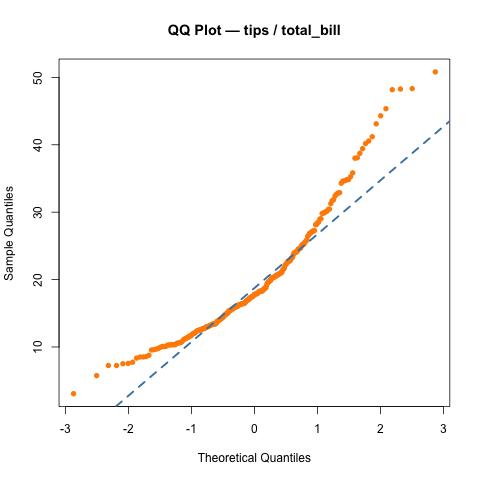

In [ ]:
# ===== Egzersiz 4 (R) =====
%%R -i tips

bill <- tips$total_bill
qqnorm(bill, main = "QQ Plot — tips / total_bill", col = "darkorange", pch = 16)
qqline(bill, col = "steelblue", lwd = 2.5, lty = 2)

# Bakılan Q-Q Grafiği bize verinin normal dağılıma uyup uymadığını görsel olarak gösterir. Eğer veri normal dağılıma uygunsa, noktalar yaklaşık olarak kırmızı çizgiye yakın bir şekilde hizalanır.
# Bakılan grafikte ise noktalar mavi çizgiden sapmalar gösteriyor, bu da verinin normal dağılıma uymadığını gösteriyor. Özellikle sağa çarpıklık (right-skewed) gözlemleniyor.

## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 2–3 | En kapsamlı açıklama |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | Ders 2–4 | Video |
| [Seeing Theory](https://seeing-theory.brown.edu) | Distributions | İnteraktif görselleştirme |
| [DuckDB Docs](https://duckdb.org/docs/sql/functions/aggregates) | Window Functions | SQL referans |